In [1]:
import logic.pulsed.pulse_objects as po
from logic.pulsed.sampling_functions import SamplingFunctions as SF
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
pjl = pulsedjupyterlogic_AWG #Make sure the Logic is started in the Qudi manager!!!!
import pickle
import datetime
from logic import gwyfile as gwy
import numpy as np
from scipy.signal import find_peaks
from hardware.timetagger_counter import HWRecorderMode

###### Measurement parameters

In [2]:
#measurement parameters
pi_pulse = 88e-9

#Driving information for the first LO (SGS)
target_freq_0 = 1.03726e9 #initial resonance frequency
LO_freq_0 = target_freq_0 + 100e6
power_0 = -15

#Information for running full PODMR
mw_start = 1.02e9
mw_stop = 1.06e9
mw_step = 1e6

tau_start = 0
tau_stop = 600e-9
tau_num = 60

max_sweeps_podmr =150e3 #Number of sweeps for tracking pulsed measurements
max_sweeps_pulsed_measurement =150e3 #Number of sweeps for T2 related pulsed measurements

#Scan area
power_start = -25
power_stop = -10
power_step = 0.2

lift_off = False
lift_off_height = 5e-9
lift_off_check_period = 60 #Define period, where the lift off is checked again
tip_oscillation_off = False #Define, whether the tip oscillation is turned of during lift off
turn_off_wait = 0.5
turn_on_wait = 0.5

retract = False

#additional information for save tag
tip_name = 'A-F17-26'
sample = 'NbSe2_S6'
temperature = '2.5K'
b_field = '70mT_Bnv_sFC'
contact = 'OOC'
extra = ''

afm_scanner_logic.jupyter_meas_stop = False
afm_scanner_logic.jupyter_meas_pause = False

###### Helper functions

In [3]:
def update_pulsed_gui(elapsed_time, elapsed_sweeps, raw_data):
    pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_time = elapsed_time
    pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_sweeps = elapsed_sweeps
    pulsedmeasurementlogic_AWG.raw_data = raw_data
    
    return_dict = pulsedmeasurementlogic_AWG._pulseextractor.extract_laser_pulses(pulsedmeasurementlogic_AWG.raw_data)
    pulsedmeasurementlogic_AWG.laser_data = return_dict['laser_counts_arr']

    tmp_signal, tmp_error = pulsedmeasurementlogic_AWG._analyze_laser_pulses()

    # exclude laser pulses to ignore
    if len(pulsedmeasurementlogic_AWG._laser_ignore_list) > 0:
        # Convert relative negative indices into absolute positive indices
        while pulsedmeasurementlogic_AWG._laser_ignore_list[0] < 0:
            neg_index = pulsedmeasurementlogic_AWG._laser_ignore_list[0]
            pulsedmeasurementlogic_AWG._laser_ignore_list[0] = len(tmp_signal) + neg_index
            pulsedmeasurementlogic_AWG._laser_ignore_list.sort()

        tmp_signal = np.delete(tmp_signal, pulsedmeasurementlogic_AWG._laser_ignore_list)
        tmp_error = np.delete(tmp_error, pulsedmeasurementlogic_AWG._laser_ignore_list)

    # order data according to alternating flag
    if pulsedmeasurementlogic_AWG._alternating:
        if len(pulsedmeasurementlogic_AWG.signal_data[0]) != len(tmp_signal[::2]):
            pulsedmeasurementlogic_AWG.log.error('Length of controlled variable ({0}) does not match length of number of readout '
                           'pulses ({1}).'.format(len(pulsedmeasurementlogic_AWG.signal_data[0]), len(tmp_signal[::2])))
            return
        pulsedmeasurementlogic_AWG.signal_data[1] = tmp_signal[::2]
        pulsedmeasurementlogic_AWG.signal_data[2] = tmp_signal[1::2]
        pulsedmeasurementlogic_AWG.measurement_error[1] = tmp_error[::2]
        pulsedmeasurementlogic_AWG.measurement_error[2] = tmp_error[1::2]
    else:
        if len(pulsedmeasurementlogic_AWG.signal_data[0]) != len(tmp_signal):
            pulsedmeasurementlogic_AWG.log.error('Length of controlled variable ({0}) does not match length of number of readout '
                           'pulses ({1}).'.format(len(pulsedmeasurementlogic_AWG.signal_data[0]), len(tmp_signal)))
            return
        pulsedmeasurementlogic_AWG.signal_data[1] = tmp_signal
        pulsedmeasurementlogic_AWG.measurement_error[1] = tmp_error

    # Compute alternative data array from signal
    pulsedmeasurementlogic_AWG._compute_alt_data()

    # emit signals
    pulsedmeasurementlogic_AWG.sigTimerUpdated.emit(pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_time, pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_sweeps,
                          pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__timer_interval)
    pulsedmeasurementlogic_AWG.sigMeasurementDataUpdated.emit()

def prepare_AWG_sequence_mode(tau_start, tau_stop, tau_num, pi_pulse,init_res_freq, mw_start, mw_stop, mw_step, power):
    
    ensemble_list = []
    tau_arr_list = []
    alternating_list = []
    freq_sweep_list = []
    index_list = []
    explicit_steps_list = []
    loop_number_list = []
    measurement_type_list = []
    former_pulsed_measurement_info = {}
    
#     uploaded_sequence_step_list = pjl.AWG._current_uploaded_sequence_step_list
    
    #Remove the tracking sequence step, if it excists. This allows to run the scan several times in a row without breaking it
#     for idx, sequence_step in enumerate(uploaded_sequence_step_list):
#         if podmr_tracking_name in sequence_step['step_segment']:
#             del uploaded_sequence_step_list[idx]
            
#     #Check, if there is something uplouded on the AWG
#     if len(uploaded_sequence_step_list) == 0:
#         afm_scanner_logic._mw.off()
#         pjl._pulsed_master_AWG.pulsedmeasurementlogic().pulsegenerator().pulser_off()
#         pjl._pulsed_master.pulsedmeasurementlogic().pulsegenerator().pulser_off()  
#         afm_scanner_logic.jupyter_meas_stop = True
#         print('No sequence is uploaded on the AWG to be played in arb. sequence Z liftoff scan.') 
#         return

#     pjl.initialize_ensemble(laser_power_voltage = podmrlogic.laser_power_voltage, pi_pulse=pi_pulse, LO_freq_0=init_res_freq + 100e6, target_freq_0=init_res_freq, power_0=power, printing = False, upload = False, set_up_measurement = False)
#     pjl.Rabi(tau_start, tau_stop, tau_num)
    
    point_by_point_several_sequences_measurement = False
    if pjl.point_by_point_several_sequences_measurement:
        point_by_point_sequence_step_list = pjl.transformed_several_sequences_step_list.copy()
        point_by_point_sequence_step_list_alt = pjl.transformed_several_sequences_step_list_alt.copy()
        loop_number_list = pjl.loop_number_list.copy()
        
        explicit_steps_list = point_by_point_sequence_step_list.copy()
        explicit_steps_list = explicit_steps_list + point_by_point_sequence_step_list_alt.copy()
        measurement_type_list.append('point_by_point_several_sequences_measurement')
        former_pulsed_measurement_info['measurement_type'] = 'point_by_point_several_sequences_measurement'
        former_pulsed_measurement_info['point_by_point_sequence_step_list'] = pjl.transformed_several_sequences_step_list.copy()
        former_pulsed_measurement_info['point_by_point_sequence_step_list_alt'] = pjl.transformed_several_sequences_step_list_alt.copy()
        point_by_point_several_sequences_measurement = True
        
    elif pjl.point_by_point_large_sequence_measurement:
        explicit_steps_list = pjl.sequence_step_list.copy()
        measurement_type_list.append('point_by_point_large_sequence_measurement')
        former_pulsed_measurement_info['measurement_type'] = 'point_by_point_large_sequence_measurement'
    else:
        explicit_steps_list = pjl.sequence_step_list.copy()
        measurement_type_list.append('sweeping_measurement')
        former_pulsed_measurement_info['measurement_type'] = 'sweeping_measurement'
        
    
    
    tracking_step = len(explicit_steps_list)
    ensemble_name = pulsedmeasurement_AWG._mw.current_loaded_asset_Label.text().strip()
    ensemble_list.append(ensemble_name)
    tau_arr_list.append(pjl.tau_arr)
    alternating_list.append(pjl.alternating)
    freq_sweep_list.append(pjl.freq_sweep)
    former_pulsed_measurement_info['sequence_step_list'] = pjl.sequence_step_list.copy()
    former_pulsed_measurement_info['tau_arr'] = pjl.tau_arr.copy()
    former_pulsed_measurement_info['alternating'] = pjl.alternating
    former_pulsed_measurement_info['freq_sweep'] = pjl.freq_sweep
    former_pulsed_measurement_info['ensemble_name'] = ensemble_name
  
    index_list.append(0)
    
    #Upload and prepare the AWG and pulsestreamer for the PODMR sequence for tracking the res. frequency.
    podmr_tracking_name ='podmr-z-liftoff-scan'
    pjl.initialize_ensemble(laser_power_voltage = podmrlogic.laser_power_voltage, pi_pulse=pi_pulse, LO_freq_0=init_res_freq + 100e6, target_freq_0=init_res_freq, power_0=power, printing = False, upload = False, set_up_measurement = False)
    AWG_ensemble_list, AWG_sequence_step_list, PS_seq_name, tau_arr, alternating, freq_sweep = pjl.PODMR(mw_start, mw_stop, mw_step, podmr_tracking_name)

    explicit_steps_list.append({"step_index" : tracking_step,
                "step_segment" : AWG_ensemble_list[0],
                "step_loops" : 1,
                "next_step_index" : tracking_step,
                "step_end_cond" : 'always'
                })
    
    ensemble_list.append(AWG_ensemble_list[0])
    tau_arr_list.append(tau_arr)
    alternating_list.append(alternating)
    freq_sweep_list.append(freq_sweep)
    index_list.append(tracking_step)
    measurement_type_list.append('sweeping_measurement')
    
    sequence_step_list = explicit_steps_list
    pjl.AWG_MW_reset()
    pjl.AWG.load_ready_sequence_mode(sequence_step_list)
    pjl.sample_load_ready_pulsestreamer(name='read_out_jptr')
    
    if point_by_point_several_sequences_measurement:
        sequence_step_list = []
        sequence_step_list.append(point_by_point_sequence_step_list)
        sequence_step_list.append(point_by_point_sequence_step_list_alt)

    return measurement_type_list, ensemble_list, tau_arr_list, alternating_list, freq_sweep_list, sequence_step_list, index_list, loop_number_list, former_pulsed_measurement_info

def retrive_former_pulsed_measurement_info(former_pulsed_measurement_info):
    if former_pulsed_measurement_info['measurement_type'] == 'point_by_point_several_sequences_measurement':
        pjl.point_by_point_several_sequences_measurement = True
        pjl.point_by_point_large_sequence_measurement = False
        pjl.transformed_several_sequences_step_list = former_pulsed_measurement_info['point_by_point_sequence_step_list'].copy()
        pjl.transformed_several_sequences_step_list_alt = former_pulsed_measurement_info['point_by_point_sequence_step_list_alt'].copy()
    elif former_pulsed_measurement_info['measurement_type'] == 'point_by_point_large_sequence_measurement':
        pjl.point_by_point_several_sequences_measurement = False
        pjl.point_by_point_large_sequence_measurement = True
        
    pjl.sequence_step_list = former_pulsed_measurement_info['sequence_step_list'].copy()
    pjl.tau_arr = former_pulsed_measurement_info['tau_arr'].copy()
    pjl.alternating = former_pulsed_measurement_info['alternating']
    pjl.freq_sweep = former_pulsed_measurement_info['freq_sweep']
    pjl.pulsed_master_AWG.sigUpdateLoadedAssetLabel.emit('  '+former_pulsed_measurement_info['ensemble_name'], '')
        

def run_measurement(measurement_type, idx, AWG_ensemble_name, tau_arr, loop_number_list, sequence_step_list, alternating, freq_sweep, res_freq, power, max_sweeps, lift_off_check_period = 0, change_freq = True):
    if measurement_type == 'point_by_point_several_sequences_measurement':
        return run_point_by_point_several_sequences_measurement(idx, AWG_ensemble_name, tau_arr, loop_number_list, sequence_step_list, alternating, freq_sweep, res_freq, power, max_sweeps, lift_off_check_period, change_freq)
    elif measurement_type ==  'point_by_point_large_sequence_measurement':
        return run_point_by_point_large_sequence_measurement(idx, AWG_ensemble_name, tau_arr, alternating, freq_sweep, res_freq, power, max_sweeps, lift_off_check_period, change_freq)
    else:
        return run_sweeping_measurement(idx, AWG_ensemble_name, tau_arr, alternating, freq_sweep, res_freq, power, max_sweeps, lift_off_check_period, change_freq)
    
def run_sweeping_measurement(idx, AWG_ensemble_name, tau_arr, alternating, freq_sweep, res_freq, power, max_sweeps, lift_off_check_period = 0, change_freq = True):
    #Setup measurement
    tau_num = len(tau_arr) * 2 if alternating else len(tau_arr)
    pjl.pulsed_master_AWG.set_fast_counter_settings(record_length=pjl.read_out_time+pjl.add_tt_read_out, number_of_gates=tau_num)
    pjl.pulsed_master_AWG.set_measurement_settings(invoke_settings=False, 
                                controlled_variable=tau_arr,
                                number_of_lasers=tau_num, 
                                laser_ignore_list=[], 
                                alternating=alternating, 
                                units=('Hz' if freq_sweep else 's', 'arb. u.'))
    pjl.pulsed_master_AWG.pulsedmeasurementlogic().alternative_data_type = 'None'
    pjl.AWG.instance.set_sequence_start_step(idx)
        
    if change_freq:
        pjl.pulsed_master_AWG.set_ext_microwave_settings(use_ext_microwave=True, 
                                                frequency=res_freq + 100e6,
                                                power=power)
    
    TF_Amp = spm._dev.afm.getTFExcitationAmplitude()
    pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_sweeps = 0
    
    #Lift off
    lift_off_start = 0
    if lift_off_height > 0 and lift_off:
        do_lift_off(lift_off_height)
        if tip_oscillation_off:
            spm._dev.afm.setTFExcitationAmplitude(0)
            time.sleep(turn_off_wait)
        lift_off_start = time.time()
    
    #Start measuremenet
    pjl.start_measurement(measurement_type=AWG_ensemble_name, tip_name=tip_name, sample=sample, 
                          temperature=temperature, b_field=b_field, contact=contact, extra=extra+f'_power_{power}dBm', printing = False)

    while True:
        if abs(lift_off_start-time.time())>=lift_off_check_period and lift_off_height > 0 and lift_off_check_period > 0 and lift_off:
            pulsedmeasurementlogic_AWG.pause_pulsed_measurement()
            if tip_oscillation_off:
                spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
                time.sleep(turn_on_wait)
            go_into_contact()
            do_lift_off(lift_off_height)
            if tip_oscillation_off:
                spm._dev.afm.setTFExcitationAmplitude(0)
                time.sleep(turn_off_wait)
            lift_off_start = time.time()
            pulsedmeasurementlogic_AWG.continue_pulsed_measurement()
            
        if fastcounter_time_tagger.pulsed.getCounts()>max_sweeps or afm_scanner_logic.jupyter_meas_stop:
            pulsedmeasurementlogic_AWG.stop_pulsed_measurement()
            if lift_off_height > 0 and lift_off:
                if tip_oscillation_off:
                    spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
                    time.sleep(turn_on_wait)
                go_into_contact()
            if alternating:
                pjl.pulsed_master_AWG.pulsedmeasurementlogic().alternative_data_type = 'Delta'
            pulsedmeasurement_AWG.save_clicked() #Save measurement in qudi data file
            result = afm_scanner_logic.analyse_pulsed_meas(pulsedmasterlogic_AWG.analysis_settings, pulsedmeasurementlogic_AWG.laser_data, alternating)
            if alternating:
                return pulsedmeasurementlogic_AWG.signal_data[1], pulsedmeasurementlogic_AWG.signal_data[2], pulsedmeasurementlogic_AWG.signal_data[1] - pulsedmeasurementlogic_AWG.signal_data[2]
            else:
                return pulsedmeasurementlogic_AWG.signal_data[1], 0, 0
        else:
            time.sleep(0.001)
            
def run_point_by_point_several_sequences_measurement(idx, AWG_ensemble_name, tau_arr, loop_number_list, sequence_step_list, alternating, freq_sweep, res_freq, power, max_sweeps, lift_off_check_period = 0, change_freq = True):
    #Setup measurement
    tau_num = len(tau_arr) * 2 if alternating else len(tau_arr)
    pjl.pulsed_master_AWG.set_fast_counter_settings(record_length=pjl.read_out_time+pjl.add_tt_read_out, number_of_gates=tau_num)
    pjl.pulsed_master_AWG.set_measurement_settings(invoke_settings=False, 
                                controlled_variable=tau_arr,
                                number_of_lasers=tau_num, 
                                laser_ignore_list=[], 
                                alternating=alternating, 
                                units=('Hz' if freq_sweep else 's', 'arb. u.'))
    pjl.pulsed_master_AWG.pulsedmeasurementlogic().alternative_data_type = 'None'
        
    if change_freq:
        pjl.pulsed_master_AWG.set_ext_microwave_settings(use_ext_microwave=True, 
                                                frequency=res_freq + 100e6,
                                                power=power)
        
    time.sleep(0.1)
    pjl.pulsed_measurement_logic_AWG.point_by_point_measurement = True
    
    save_tag = AWG_ensemble_name

    if tip_name:
        save_tag += '_'+tip_name
    if sample:
        save_tag += '_'+sample
    if temperature:
        save_tag += '_'+temperature
    if b_field:
        save_tag += '_'+b_field
    if contact:
        save_tag += '_'+contact
    if extra:
        save_tag += '_'+extra+f'_power_{power}dBm'

    pjl.pulsed_master_AWG.sigUpdateSaveTag.emit(save_tag)
    pjl.pulsed_master_AWG.sigUpdateLoadedAssetLabel.emit('  '+AWG_ensemble_name, '')
    
    n_var = len(loop_number_list)*2 if alternating else len(loop_number_list)
    n_bins = 1+int((pjl.read_out_time + pjl.add_tt_read_out)/pjl.bin_width)
    raw_data = np.zeros((n_var, n_bins), dtype='int64')

    pjl.pulsed_measurement_logic_AWG.do_fit('No Fit', False)
    pjl.pulsed_measurement_logic_AWG.do_fit('No Fit', True)

    pjl.pulsed_measurement_logic_AWG._initialize_data_arrays()
    pjl.pulsed_measurement_logic_AWG._recalled_raw_data_tag = None

    pjl.fastcounter.configure(pjl.bin_width, pjl.read_out_time + pjl.add_tt_read_out, 1)
    
    if pjl.switch_MW:
        pjl.mw1.cw_on()
    else:
        pjl.mw.cw_on()
        
    uploaded_segment_and_index = pjl.AWG._current_uploaded_segment_and_index.copy()
    gui_update_interval = pjl.pulsed_measurement_logic_AWG._PulsedMeasurementLogic__timer_interval
    
    TF_Amp = spm._dev.afm.getTFExcitationAmplitude()
    
    #Lift off
    lift_off_start = 0
    if lift_off_height > 0 and lift_off:
        do_lift_off(lift_off_height)
        if tip_oscillation_off:
            spm._dev.afm.setTFExcitationAmplitude(0)
            time.sleep(turn_off_wait)
        lift_off_start = time.time()
        
    time_start = time.time()
    for loop_idx, loop_num in enumerate(loop_number_list):
        pjl.fastcounter.start_measure()
        for istep, step in enumerate(sequence_step_list[0]):
            step_index = step['step_index']
            mem_segment_index = uploaded_segment_and_index[step['step_segment']]
            if pjl.sweeping_tag in step['step_segment']:
                loops = loop_num
            else:
                loops = step['step_loops']
            goto = step['next_step_index']
            next_condition = step['step_end_cond']
            pjl.AWG.instance.write_sequence_step(step_index, mem_segment_index, loops, goto, next_condition)


        pjl.AWG.instance.set_sequence_start_step(idx)
        gui_update_interval_start = time.time()
        pjl.AWG.pulser_on()
        while True:
            if abs(lift_off_start-time.time())>=lift_off_check_period and lift_off_height > 0 and lift_off_check_period > 0 and lift_off:
                pjl.AWG.pulser_off()
                if tip_oscillation_off:
                    spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
                    time.sleep(turn_on_wait)
                go_into_contact()
                do_lift_off(lift_off_height)
                if tip_oscillation_off:
                    spm._dev.afm.setTFExcitationAmplitude(0)
                    time.sleep(turn_off_wait)
                lift_off_start = time.time()
                pjl.AWG.pulser_on()
            elapsed_time = time.time() - time_start
            elapsed_sweeps = pjl.fastcounter.pulsed.getCounts()
            if elapsed_sweeps>max_sweeps or afm_scanner_logic.jupyter_meas_stop:
                    pjl.AWG.pulser_off()
                    pjl.fastcounter.stop_measure()
                    if alternating:
                        raw_data[loop_idx*2] = np.array(pjl.fastcounter.pulsed.getData(),dtype = 'int64')
                    else:
                        raw_data[loop_idx] = np.array(pjl.fastcounter.pulsed.getData(),dtype = 'int64')
                    pjl.update_pulsed_gui(elapsed_time, elapsed_sweeps, raw_data)
                    break

            if time.time() - gui_update_interval_start>gui_update_interval:
                if alternating:
                    raw_data[loop_idx*2] = np.array(pjl.fastcounter.pulsed.getData(),dtype = 'int64')
                else:
                    raw_data[loop_idx] = np.array(pjl.fastcounter.pulsed.getData(),dtype = 'int64')
                pjl.update_pulsed_gui(elapsed_time, elapsed_sweeps, raw_data)
                gui_update_interval_start = time.time()



        if afm_scanner_logic.jupyter_meas_stop:
            break

        if alternating:
            pjl.fastcounter.start_measure()
            for istep, step in enumerate(sequence_step_list[1]):
                step_index = step['step_index']
                mem_segment_index = uploaded_segment_and_index[step['step_segment']]
                if pjl.sweeping_tag in step['step_segment']:
                    loops = loop_num
                else:
                    loops = step['step_loops']
                goto = step['next_step_index']
                next_condition = step['step_end_cond']
                pjl.AWG.instance.write_sequence_step(step_index, mem_segment_index, loops, goto, next_condition)

            pjl.AWG.instance.set_sequence_start_step(idx)
            gui_update_interval_start = time.time()
            pjl.AWG.pulser_on()
            while True:
                if abs(lift_off_start-time.time())>=lift_off_check_period and lift_off_height > 0 and lift_off_check_period > 0 and lift_off:
                    pjl.AWG.pulser_off()
                    if tip_oscillation_off:
                        spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
                        time.sleep(turn_on_wait)
                    go_into_contact()
                    do_lift_off(lift_off_height)
                    if tip_oscillation_off:
                        spm._dev.afm.setTFExcitationAmplitude(0)
                        time.sleep(turn_off_wait)
                    lift_off_start = time.time()
                    pjl.AWG.pulser_on()
                elapsed_time = time.time() - time_start
                elapsed_sweeps = pjl.fastcounter.pulsed.getCounts()
                if elapsed_sweeps>max_sweeps or afm_scanner_logic.jupyter_meas_stop:
                        pjl.AWG.pulser_off()
                        pjl.fastcounter.stop_measure()
                        raw_data[(loop_idx*2)+1] = np.array(pjl.fastcounter.pulsed.getData(),dtype = 'int64')
                        pjl.update_pulsed_gui(elapsed_time, elapsed_sweeps, raw_data)
                        break

                if time.time() -gui_update_interval_start >gui_update_interval:
                    raw_data[(loop_idx*2)+1] = np.array(pjl.fastcounter.pulsed.getData(),dtype = 'int64')
                    pjl.update_pulsed_gui(elapsed_time, elapsed_sweeps, raw_data)
                    gui_update_interval_start = time.time()

            if afm_scanner_logic.jupyter_meas_stop:
                break

    pjl.mw1.off()
    pjl.mw.off()
    pjl.pulsed_measurement_logic_AWG.point_by_point_measurement = False
    
    if lift_off_height > 0 and lift_off:
        if tip_oscillation_off:
            spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
            time.sleep(turn_on_wait)
        go_into_contact()
        
    pjl.update_pulsed_gui(elapsed_time, elapsed_sweeps, raw_data)
    if alternating:
        pjl.pulsed_master_AWG.pulsedmeasurementlogic().alternative_data_type = 'Delta'
    time.sleep(1)
    pulsedmeasurement_AWG.save_clicked() #Save measurement in qudi data file
    if alternating:
        return pulsedmeasurementlogic_AWG.signal_data[1], pulsedmeasurementlogic_AWG.signal_data[2], pulsedmeasurementlogic_AWG.signal_data[1] - pulsedmeasurementlogic_AWG.signal_data[2]
    else:
        return pulsedmeasurementlogic_AWG.signal_data[1], 0, 0
    
def run_point_by_point_large_sequence_measurement(idx, AWG_ensemble_name, tau_arr, alternating, freq_sweep, res_freq, power, max_sweeps, lift_off_check_period = 0, change_freq = True):
    #Setup measurement
    tau_num = len(tau_arr) * 2 if alternating else len(tau_arr)
    pjl.pulsed_master_AWG.set_fast_counter_settings(record_length=pjl.read_out_time+pjl.add_tt_read_out, number_of_gates=tau_num)
    pjl.pulsed_master_AWG.set_measurement_settings(invoke_settings=False, 
                                controlled_variable=tau_arr,
                                number_of_lasers=tau_num, 
                                laser_ignore_list=[], 
                                alternating=alternating, 
                                units=('Hz' if freq_sweep else 's', 'arb. u.'))
    pjl.pulsed_master_AWG.pulsedmeasurementlogic().alternative_data_type = 'None'
        
    if change_freq:
        pjl.pulsed_master_AWG.set_ext_microwave_settings(use_ext_microwave=True, 
                                                frequency=res_freq + 100e6,
                                                power=power)
        
    time.sleep(0.1)
    pjl.pulsed_measurement_logic_AWG.point_by_point_measurement = True
    
    save_tag = AWG_ensemble_name

    if tip_name:
        save_tag += '_'+tip_name
    if sample:
        save_tag += '_'+sample
    if temperature:
        save_tag += '_'+temperature
    if b_field:
        save_tag += '_'+b_field
    if contact:
        save_tag += '_'+contact
    if extra:
        save_tag += '_'+extra+'_power_{power}dBm'

    pjl.pulsed_master_AWG.sigUpdateSaveTag.emit(save_tag)
    pjl.pulsed_master_AWG.sigUpdateLoadedAssetLabel.emit('  '+AWG_ensemble_name, '')
    
    n_bins = 1+int((pjl.read_out_time + pjl.add_tt_read_out)/pjl.bin_width)
    raw_data = np.zeros((tau_num, n_bins), dtype='int64')

    pjl.pulsed_measurement_logic_AWG.do_fit('No Fit', False)
    pjl.pulsed_measurement_logic_AWG.do_fit('No Fit', True)

    pjl.pulsed_measurement_logic_AWG._initialize_data_arrays()
    pjl.pulsed_measurement_logic_AWG._recalled_raw_data_tag = None

    pjl.fastcounter.configure(pjl.bin_width, pjl.read_out_time + pjl.add_tt_read_out, 1)
    
    if pjl.switch_MW:
        pjl.mw1.cw_on()
    else:
        pjl.mw.cw_on()
        
    gui_update_interval = pjl.pulsed_measurement_logic_AWG._PulsedMeasurementLogic__timer_interval
    
    TF_Amp = spm._dev.afm.getTFExcitationAmplitude()
    
    #Lift off
    lift_off_start = 0
    if lift_off_height > 0 and lift_off:
        do_lift_off(lift_off_height)
        if tip_oscillation_off:
            spm._dev.afm.setTFExcitationAmplitude(0)
            time.sleep(turn_off_wait)
        lift_off_start = time.time()
        
    time_start = time.time()
    for idx, tau in enumerate(tau_arr):
        if alternating:
            pjl.AWG.instance.set_sequence_start_step(idx*2)
        else:
            pjl.AWG.instance.set_sequence_start_step(idx)
        pjl.fastcounter.start_measure()
        
        gui_update_interval_start = time.time()
        pjl.AWG.pulser_on()
        while True:
            if abs(lift_off_start-time.time())>=lift_off_check_period and lift_off_height > 0 and lift_off_check_period > 0 and lift_off:
                pjl.AWG.pulser_off()
                if tip_oscillation_off:
                    spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
                    time.sleep(turn_on_wait)
                go_into_contact()
                do_lift_off(lift_off_height)
                if tip_oscillation_off:
                    spm._dev.afm.setTFExcitationAmplitude(0)
                    time.sleep(turn_off_wait)
                lift_off_start = time.time()
                pjl.AWG.pulser_on()
            elapsed_time = time.time() - time_start
            elapsed_sweeps = pjl.fastcounter.pulsed.getCounts()
            if elapsed_sweeps>max_sweeps or afm_scanner_logic.jupyter_meas_stop:
                    pjl.AWG.pulser_off()
                    pjl.fastcounter.stop_measure()
                    if alternating:
                        raw_data[idx*2] = np.array(pjl.fastcounter.pulsed.getData(),dtype = 'int64')
                    else:
                        raw_data[idx] = np.array(pjl.fastcounter.pulsed.getData(),dtype = 'int64')
                    pjl.update_pulsed_gui(elapsed_time, elapsed_sweeps, raw_data)
                    break

            if time.time() - gui_update_interval_start>gui_update_interval:
                if alternating:
                    raw_data[idx*2] = np.array(pjl.fastcounter.pulsed.getData(),dtype = 'int64')
                else:
                    raw_data[idx] = np.array(pjl.fastcounter.pulsed.getData(),dtype = 'int64')
                pjl.update_pulsed_gui(elapsed_time, elapsed_sweeps, raw_data)
                gui_update_interval_start = time.time()



        if afm_scanner_logic.jupyter_meas_stop:
            break

        if alternating:
            pjl.AWG.instance.set_sequence_start_step(idx*2+1)
            pjl.fastcounter.start_measure()
            gui_update_interval_start = time.time()
            pjl.AWG.pulser_on()
            while True:
                if abs(lift_off_start-time.time())>=lift_off_check_period and lift_off_height > 0 and lift_off_check_period > 0 and lift_off:
                    pjl.AWG.pulser_off()
                    if tip_oscillation_off:
                        spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
                        time.sleep(turn_on_wait)
                    go_into_contact()
                    do_lift_off(lift_off_height)
                    if tip_oscillation_off:
                        spm._dev.afm.setTFExcitationAmplitude(0)
                        time.sleep(turn_off_wait)
                    lift_off_start = time.time()
                    pjl.AWG.pulser_on()
                elapsed_time = time.time() - time_start
                elapsed_sweeps = pjl.fastcounter.pulsed.getCounts()
                if elapsed_sweeps>max_sweeps or afm_scanner_logic.jupyter_meas_stop:
                        pjl.AWG.pulser_off()
                        pjl.fastcounter.stop_measure()
                        raw_data[(idx*2)+1] = np.array(pjl.fastcounter.pulsed.getData(),dtype = 'int64')
                        pjl.update_pulsed_gui(elapsed_time, elapsed_sweeps, raw_data)
                        break

                if time.time() -gui_update_interval_start >gui_update_interval:
                    raw_data[(idx*2)+1] = np.array(pjl.fastcounter.pulsed.getData(),dtype = 'int64')
                    pjl.update_pulsed_gui(elapsed_time, elapsed_sweeps, raw_data)
                    gui_update_interval_start = time.time()

            if afm_scanner_logic.jupyter_meas_stop:
                break

    pjl.mw1.off()
    pjl.mw.off()
    pjl.pulsed_measurement_logic_AWG.point_by_point_measurement = False
    
    if lift_off_height > 0 and lift_off:
        if tip_oscillation_off:
            spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
            time.sleep(turn_on_wait)
        go_into_contact()
        
    pjl.update_pulsed_gui(elapsed_time, elapsed_sweeps, raw_data)
    if alternating:
        pjl.pulsed_master_AWG.pulsedmeasurementlogic().alternative_data_type = 'Delta'
    time.sleep(1)
    pulsedmeasurement_AWG.save_clicked() #Save measurement in qudi data file
    if alternating:
        return pulsedmeasurementlogic_AWG.signal_data[1], pulsedmeasurementlogic_AWG.signal_data[2], pulsedmeasurementlogic_AWG.signal_data[1] - pulsedmeasurementlogic_AWG.signal_data[2]
    else:
        return pulsedmeasurementlogic_AWG.signal_data[1], 0, 0

def tracking_analysis(pulsed_ret0, slope2_podmr, prev):
    visibility = (pulsed_ret0[1] - pulsed_ret0[0])/(pulsed_ret0[1] + pulsed_ret0[0])
    new_res_freq =  prev - visibility/slope2_podmr

    return new_res_freq, visibility

def PODMR_analysis(data, var_list, mode ='gaussian_dip'):
    try:
        if mode == 'double':
            fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_dip)

        elif mode == 'N15':
            fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N15)

        elif mode == 'N14':
            fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N14)

        elif mode == 'gaussian_dip':
            fit = afm_scanner_logic._fitlogic.make_gaussian_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_gaussian_dip)
        res_freq = fit.params['center'].value
    except:
        res_freq = var_list[np.argmin(data)]
    
    return res_freq

def goto(x_pos, y_pos):
    while True:
        if spm._dev.base.getParameter(spm._dev.base.getConst('ID_SCAN_STATUS'), 0)==2:
            time.sleep(0.001)
        else:
            break
    afm_scanner_logic.set_afm_pos({'x':x_pos, 'y':y_pos})
    time.sleep(0.001)
    while True:
        if spm._dev.base.getParameter(spm._dev.base.getConst('ID_SCAN_STATUS'), 0)==2:
            time.sleep(0.001)
        else:
            break

def get_topo(reps=5):
    topo = 0
    for i in range(reps):
        topo = topo + spm.get_sample_pos()['Z']
        time.sleep(0.005)
    return spm.get_sample_scan_range()['Z'] - topo/reps

def get_pos(reps=5):
    pos = 0
    for i in range(reps):
        pos = pos+ spm.get_sample_pos()['Z']
        time.sleep(0.005)
    return pos/reps

def go_into_contact():
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_AAP_CTRL'), 1, 0)
    while not spm.is_probe_landed():
        time.sleep(0.001)
    time.sleep(0.5)
        
def do_lift_off(lift_off_height):
    pos = get_pos()
    new_pos = pos - lift_off_height
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_LOOP_ON'), 0, 0)
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_SET_Z_M'), new_pos*1e12, 0)
    

def setup_autoapproach():
    #configuration of autoapproach settings
    # for HFAmpl signal
    threshold = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_SETP_DISP')) / 1e7
    spm._dev.aap.setAApThreshold(threshold)

    # dF     8
    # HFAmpl       13
    input_signal = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_INPUT'))
    threshold_cond = 1 if input_signal==13 else 0        
    spm._dev.aap.setAApStopCondition(threshold_cond) # [0, 1] >threshold/<threshold
    spm._dev.aap.setAApStepsPerApproach(0)

    spm._dev.aap.setAApAproachMode(1) # [0, 1] Ramp/Loop
    spm._dev.aap.setAApModeAfter(0) # [0, 1, 2] On/Retract/Off

def measurement_loop(power_start, power_stop, power_step, tau_start, tau_stop, tau_num, power_podmr, pi_pulse, init_res_freq, mw_start, mw_stop, mw_step, max_sweeps_podmr, max_sweeps_pulsed_measurement, lift_off, lift_off_check_period, path, retract):
    afm_scanner_logic.jupyter_meas_stop = False
    afm_scanner_logic.jupyter_meas_pause = False
    
    power_arr = np.arange(power_start, power_stop, power_step)
    
    #Deactivate the printing of information into the manager log as this is time intensive
    awg_spectrum.print_log_info = False
    sequencegeneratorlogic_AWG.print_log_info = False
    sequencegeneratorlogic.print_log_info = False
    
    afm_scanner_logic._pulsed_master_AWG.pulsedmeasurementlogic().alternative_data_type = 'None'
    
    #Create needed sequences for the pulsestremaer and the AWG
    measurement_type_list, ensemble_list, tau_arr_list, alternating_list, freq_sweep_list, sequence_step_list, index_list, loop_number_list, former_pulsed_measurement_info = prepare_AWG_sequence_mode(tau_start, tau_stop, tau_num, pi_pulse, init_res_freq, mw_start, mw_stop, mw_step, power_podmr)
    if afm_scanner_logic.jupyter_meas_stop:
        return {}
    
    freq_list = tau_arr_list[1]
    PODMR_freq = freq_list[-1]
    
    res_freq = np.zeros((len(power_arr)))
    PODMR_sig = np.zeros((len(power_arr),len(freq_list)))
    pulsed_sig = np.zeros((len(power_arr),len(tau_arr_list[0])))
    pulsed_sig_alt = np.zeros((len(power_arr),len(tau_arr_list[0])))
    pulsed_sig_delta = np.zeros((len(power_arr),len(tau_arr_list[0])))
    
    if lift_off:
        setup_autoapproach()
        go_into_contact()
    
    start_time = datetime.datetime.now()
    
    meas_dict = {}

    measurement_type = ensemble_list[0]
    meas_dict = {'params': {'Parameters for': 'PODMR tracking and Rabi with MW power sweep for MW source calibration'}}
    meas_dict['params']['axis name for coord0'] = 'Power'
    meas_dict['params']['power_start (dBm)'] = power_start
    meas_dict['params']['power_stop (dBm)'] = power_stop
    meas_dict['params']['power_step (dBm)'] = power_step


    meas_dict['params']['PODMR MW power (dBm)'] = power_podmr
    meas_dict['params']['PODMR Pi pulse Duration (s)'] = pi_pulse
    meas_dict['params']['Initial resonance frequency (Hz)'] = init_res_freq
    meas_dict['params']['PODMR MW start (Hz)'] = mw_start
    meas_dict['params']['PODMR MW stop (Hz)'] = mw_stop
    meas_dict['params']['PODMR MW step (Hz)'] = mw_step
    meas_dict['params']['Pulsed measurement start'] = tau_arr_list[0][0]
    meas_dict['params']['Pulsed measurement stop'] = tau_arr_list[0][-1]
    meas_dict['params']['Pulsed measurement steps (#)'] = len(tau_arr_list[0])
    if freq_sweep_list[0]:
        meas_dict['params']['Pulsed measurement sweeped unit'] = 'Hz'
    else:
        meas_dict['params']['Pulsed measurement sweeped unit'] = 's'
    meas_dict['params']['Measurement runs PODMR (#)'] = max_sweeps_podmr
    meas_dict['params']['Measurement runs pulsed measurement (#)'] = max_sweeps_pulsed_measurement
    
    meas_dict['params']['Lift-off check period (s)'] =lift_off_check_period
    meas_dict['params']['Tip oscillation OFF'] = tip_oscillation_off
    meas_dict['params']['Tip oscillation turning OFF waiting time (s)'] =turn_off_wait
    meas_dict['params']['Tip oscillation turning ON waiting time (s)'] =turn_on_wait

    meas_dict['params']['Measurement start'] = start_time.isoformat('_','seconds')
    meas_dict['params']['Measurement stop'] = datetime.datetime.now().isoformat('_','seconds')

    meas_dict.update({'PODMR_sig': {'data': PODMR_sig}})
    meas_dict['PODMR_sig']['coord0_arr'] = power_arr
    meas_dict['PODMR_sig']['coord2_arr'] = tau_arr_list[1]
    meas_dict['PODMR_sig']['params'] = {'coord0_start': power_start,'coord0_stop': power_stop}
    meas_dict['PODMR_sig']['xy_units'] = 'dBm'
    meas_dict['PODMR_sig']['si_units'] = 'a.u.'
    meas_dict['PODMR_sig']['nice_name'] = 'PODMR spectrum'
    
    meas_dict.update({'res_freq': {'data': res_freq}})
    meas_dict['res_freq']['coord0_arr'] = power_arr
    meas_dict['res_freq']['params'] = {'coord0_start': power_start,'coord0_stop': power_stop}
    meas_dict['res_freq']['xy_units'] = 'dBm'
    meas_dict['res_freq']['si_units'] = 'Hz'
    meas_dict['res_freq']['nice_name'] = 'Resonance frequency'

    meas_dict.update({'pulsed_sig': {'data': pulsed_sig}})
    meas_dict['pulsed_sig']['coord0_arr'] = power_arr
    meas_dict['pulsed_sig']['coord2_arr'] = tau_arr_list[0]
    meas_dict['pulsed_sig']['params'] = {'coord0_start': power_start,'coord0_stop': power_stop}
    meas_dict['pulsed_sig']['xy_units'] = 'dBm'
    if freq_sweep_list[0]:
        meas_dict['pulsed_sig']['sweep_units'] = 'Hz'
    else:
        meas_dict['pulsed_sig']['sweep_units'] = 's'
    meas_dict['pulsed_sig']['si_units'] = 'a.u.'
    meas_dict['pulsed_sig']['nice_name'] = 'Pulsed signal'

    meas_dict.update({'pulsed_sig_alt': {'data': pulsed_sig_alt}})
    meas_dict['pulsed_sig_alt']['coord0_arr'] = power_arr
    meas_dict['pulsed_sig_alt']['coord2_arr'] = tau_arr_list[0]
    meas_dict['pulsed_sig_alt']['params'] = {'coord0_start': power_start,'coord0_stop': power_stop}
    meas_dict['pulsed_sig_alt']['xy_units'] = 'dBm'
    if freq_sweep_list[0]:
        meas_dict['pulsed_sig_alt']['sweep_units'] = 'Hz'
    else:
        meas_dict['pulsed_sig_alt']['sweep_units'] = 's'
    meas_dict['pulsed_sig_alt']['si_units'] = 'a.u.'
    meas_dict['pulsed_sig_alt']['nice_name'] = 'Pulsed signal alternating'

    meas_dict.update({'pulsed_sig_delta': {'data': pulsed_sig_delta}})
    meas_dict['pulsed_sig_delta']['coord0_arr'] = power_arr
    meas_dict['pulsed_sig_delta']['coord2_arr'] = tau_arr_list[0]
    meas_dict['pulsed_sig_delta']['params'] = {'coord0_start': power_start,'coord0_stop': power_stop}
    meas_dict['pulsed_sig_delta']['xy_units'] = 'dBm'
    if freq_sweep_list[0]:
        meas_dict['pulsed_sig_delta']['sweep_units'] = 'Hz'
    else:
        meas_dict['pulsed_sig_delta']['sweep_units'] = 's'
    meas_dict['pulsed_sig_delta']['si_units'] = 'a.u.'
    meas_dict['pulsed_sig_delta']['nice_name'] = 'Pulsed signal delta'
    
    for idz, power in enumerate(tqdm(power_arr)):
        #Pause measurement if true
        while afm_scanner_logic.jupyter_meas_pause:
            time.sleep(0.5)

        #Measure full PODMR spectrum and determine the resonance frequency by fitting
        index = 1
        PODMR_sig[idz], _, _ = run_measurement(measurement_type_list[index], index_list[index], ensemble_list[index], tau_arr_list[index], [], [], alternating_list[index], freq_sweep_list[index], PODMR_freq, power_podmr, max_sweeps_podmr, lift_off_check_period, change_freq = True)
        res_freq[idz] = PODMR_analysis(PODMR_sig[idz], freq_list) #init_res_freq
        res_freq_used = res_freq[idz] #init_res_freq

        #Measure T2
        index = 0
        pulsed_sig[idz], pulsed_sig_alt[idz], pulsed_sig_delta[idz] = run_measurement(measurement_type_list[index], index_list[index], ensemble_list[index], tau_arr_list[index], loop_number_list, sequence_step_list, alternating_list[index], freq_sweep_list[index], res_freq_used, power, max_sweeps_pulsed_measurement, lift_off_check_period, change_freq = True)
                
        #run save routine end of every fast axis loop
        meas_dict['res_freq']['data'] = res_freq
        meas_dict['PODMR_sig']['data'] = PODMR_sig
        meas_dict['pulsed_sig']['data'] = pulsed_sig
        meas_dict['pulsed_sig_alt']['data'] = pulsed_sig_alt
        meas_dict['pulsed_sig_delta']['data'] = pulsed_sig_delta

        #Pickel meas_dict
        with open(path+'.pickle', 'wb') as f:
            pickle.dump(meas_dict, f)
        
        if afm_scanner_logic.jupyter_meas_stop:
            print('Measurement force stopped')
            break
    
    #Activate the printing of information into the manager log again
    awg_spectrum.print_log_info = True
    sequencegeneratorlogic_AWG.print_log_info = True
    sequencegeneratorlogic.print_log_info = True
    awg_spectrum.pulser_off()
    mw_source_smbv.off()
    mw_source_sgs.off()
    retrive_former_pulsed_measurement_info(former_pulsed_measurement_info)
    if retract:
        spm.retract_probe()
    
    return meas_dict

def save_obj_to_gwyddion(dataobj,filename,gwytypes=['image']):
    """save_obj_to_gwyddion(): writes qudi data object to Gwyddion file
        input:  
        - dataobj: proteusQ data object of from dataobj['data_key']
        - filename: file path to save object
        - prefix:  name to be prefixed to all head objects

        requirements:
        dataobj['scan_type'] must contain keys {coord0[], coord1[], data[,], params[coord0-1_start-stop], si_units, nice_name}
    """

    # check for existance of valid object names
    datakeys = list(dataobj.keys())

    # overall object container
    objout = gwy.objects.GwyContainer()

    for dataki,datak in enumerate(sorted(datakeys, key=str.lower)):
        meas = dataobj[datak]

        # check that data is valid
        if not {'coord0_arr','coord1_arr','data'}.issubset(set(meas.keys())):
            continue 

        # check that there is non-trivial data (skip empty measurements)
        if np.sum(meas['data']) == 0.0:
            continue

        # transform data
        #scalefactor = meas['scale_fac']
        coord0 = meas['coord0_arr']
        coord1 = meas['coord1_arr']
        data_si = meas['data'] #* scalefactor

        params = meas['params']
        coord0_start = next(k for k in params.keys() if k.startswith('coord0_start'))
        coord0_stop = next(k for k in params.keys() if k.startswith('coord0_stop'))
        coord1_start = next(k for k in params.keys() if k.startswith('coord1_start'))
        coord1_stop = next(k for k in params.keys() if k.startswith('coord1_stop'))

        xy_units = meas['xy_units']
        z_units = meas['si_units']
        measname = datak + ":" + meas['nice_name']

        # encode to image
        img = gwy.objects.GwyDataField(data=data_si, si_unit_xy=xy_units, si_unit_z=z_units)
        img.xoff = params[coord0_start]
        img.xreal = params[coord0_stop] - params[coord0_start]
        img.yoff = params[coord1_start]
        img.yreal = params[coord1_stop] - params[coord1_start]

        # add to parent object 
        if 'image' in gwytypes: 
            # image types
            basekey = '/' + str(dataki) + '/data'
            objout[basekey + '/title'] = measname
            objout['/' + str(dataki) + '/base/palette'] = 'Sky'
            objout[basekey] = img
            # comment meta data
            if meas['params']:
                d = {key: str(val) for key, val in meas['params'].items()}
                meta = gwy.objects.GwyContainer(d)
                objout['/' + str(dataki) + '/meta'] = meta

    # write out file    
    if objout:
        objout.tofile(filename)

######  Run measurement

In [15]:
afm_scanner_logic.jupyter_meas_stop = False
afm_scanner_logic.jupyter_meas_pause = False

current_uploaded_measurement_string = pulsedmeasurement_AWG._mw.current_loaded_asset_Label.text().strip()
string = datetime.datetime.now().isoformat('_','seconds')+'_'+f'PODMR_Rabi_TEMP'+'_'+tip_name+'_'+sample+'_'+temperature+'_'+b_field+'_'+contact+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module('AttoDRY2200_Pi3_SPM\\')

data_array = measurement_loop(power_start, power_stop, power_step, tau_start, tau_stop, tau_num, power_0, pi_pulse, target_freq_0, mw_start, mw_stop, mw_step, max_sweeps_podmr, max_sweeps_pulsed_measurement,lift_off, lift_off_check_period, filepath+filename, retract)

######################
string = datetime.datetime.now().isoformat('_','seconds')+'_'+f'PODMR_tracking_Rabi_MW_calibration'+'_'+tip_name+'_'+sample+'_'+temperature+'_'+b_field+'_'+contact+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module('AttoDRY2200_Pi3_SPM\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(data_array, f)

100%|#####################################################################################| 75/75 [54:23<00:00, 43.51s/it]


######  Grab the data from the pickle

In [4]:
filebeginning = '2025-09-02_16-49-41_PODMR_tracking_Rabi_MW_calibration_A-F17-26_NbSe2_S6_2.5K_70mT_Bnv_sFC_OOC_' #here the beginning of the filename, including the date and sample name, is needed

file_year = filebeginning[0:4]
file_month = filebeginning[5:7]
file_day = filebeginning[8:10]
path = 'G:\\Data\\Qudi_Data\\'+file_year+'\\'+file_month+'\\'+file_year+file_month+file_day+'\\AttoDRY2200_Pi3_SPM\\'
filepath = path + filebeginning

with open(filepath+'.pickle', 'rb') as f:
    data_array = pickle.load(f)

######  Calculate Bias field and stray field

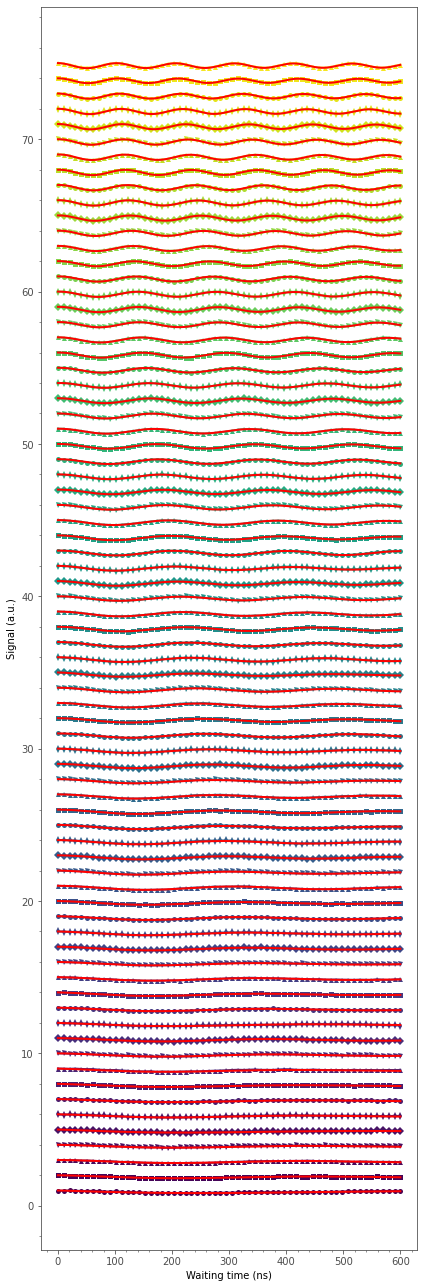

In [9]:
import matplotlib

#Analyse bias field
#Gathering data from dictonary

power_arr = data_array['PODMR_sig']['coord0_arr']
freq_list = data_array['PODMR_sig']['coord2_arr']
tau_list = data_array['pulsed_sig']['coord2_arr']
if data_array['pulsed_sig_delta']['data'].any():
    pulsed_data = data_array['pulsed_sig_delta']['data']
else:
    pulsed_data = data_array['pulsed_sig']['data']
PODMR_data = data_array['PODMR_sig']['data']

contrast = np.zeros(len(PODMR_data))
contrast_err = np.zeros(len(PODMR_data))
fwhm = np.zeros(len(PODMR_data))
fwhm_err = np.zeros(len(PODMR_data))
res_freq = np.zeros(len(PODMR_data))
res_freq_err = np.zeros(len(PODMR_data))

#Define fit function
gslac = False
left = True

mode = 'sin_exp'

fit_arg_0 = np.zeros(len(PODMR_data))
fit_arg_0_err = np.zeros(len(PODMR_data))
fit_arg_1 = np.zeros(len(PODMR_data))
fit_arg_1_err = np.zeros(len(PODMR_data))
fit_arg_2 = np.zeros(len(PODMR_data))
fit_arg_2_err = np.zeros(len(PODMR_data))

gyro_nv = 28e9 #in Hz/T
e_field = 0 #in Hz
zero_field = 2.88e9 #in Hz, watch the Temperature

fig = plt.figure(figsize = (6, 18))
# ax_HE = fig.add_subplot(projection='3d')
ax_fit_plot = fig.add_subplot()

cmap = matplotlib.cm.get_cmap('viridis')
norm = matplotlib.colors.Normalize(vmin=0, vmax=len(pulsed_data))

for idx, data in enumerate(PODMR_data):
    fit = fitlogic.make_gaussian_fit(freq_list,data,estimator=fitlogic.estimate_gaussian_dip)
    res_freq[idx] = fit.params['center'].value
    res_freq_err[idx] = fit.params['center'].stderr
    fwhm[idx] = fit.params['fwhm'].value*1e-6 #FWHM in MHz
    fwhm_err[idx] = fit.params['fwhm'].stderr*1e-6 #FWHM in MHz
    contrast[idx] = fit.params['contrast'].value*-1
    contrast_err[idx] = fit.params['contrast'].stderr
    
if gslac == True and left == True:
    b_field = np.sqrt(abs(res_freq + zero_field)**2 - e_field**2) / gyro_nv
    b_field_err = np.sqrt((((res_freq + zero_field)/(gyro_nv*np.sqrt(abs(res_freq + zero_field)**2 - e_field**2)))*res_freq_err)**2)
else:
    b_field = np.sqrt(abs(res_freq - zero_field)**2 - e_field**2) / gyro_nv
    b_field_err = np.sqrt((((res_freq - zero_field)/(gyro_nv*np.sqrt(abs(res_freq - zero_field)**2 - e_field**2)))*res_freq_err)**2)

for idx, data in enumerate(pulsed_data):
    
    rgba = cmap(norm(idx))
    tau_list_more = np.linspace(tau_list[0],tau_list[-1],len(tau_list)*100)
    
    if np.sum(data) == 0:
            continue
    #Determine fit
    if mode == 'sin_exp':
        fit = fitlogic.make_sineexponentialdecay_fit(tau_list,data,estimator=fitlogic.estimate_sineexponentialdecay)
        model,_ = fitlogic.make_sineexponentialdecay_model()
        temp = model.eval(fit.params, x=tau_list_more)
        fit_arg_0[idx] = 1/fit.params['frequency'].value
        fit_arg_0_err[idx] = 1/(fit.params['frequency'].value)**2*fit.params['frequency'].stderr
        nice_name_0 = 'Sin_exp_period'
        si_unit_0 = 's'
        fit_arg_1[idx] = ((2*fit.params['amplitude'].value)/(fit.params['offset'].value+fit.params['amplitude'].value)*100)
        fit_arg_1_err[idx] = (np.abs((2*fit.params['amplitude'].value) /
                                    (fit.params['offset'].value+fit.params['amplitude'].value)**2 *
                                     fit.params['offset'].stderr) +
                                     np.abs((2/(fit.params['offset'].value +
                                     fit.params['amplitude'].value) + (2*fit.params['amplitude'].value) /
                                     (fit.params['offset'].value + fit.params['amplitude'].value)**2) *
                                     fit.params['amplitude'].stderr))*100
        nice_name_1 = 'Sin_exp_contrast'
        si_unit_1 = '%'
    if mode == 'str_exp_envelope':
        peaks, _ = find_peaks(data, prominence=(0.02, None))#, distance=20)
        peaks = np.insert(peaks, 0, 0, axis=0)
        fit_peaks = fitlogic.make_decayexponentialstretched_fit(tau_list[peaks],data[peaks],estimator=fitlogic.estimate_decayexponentialstretched)
        model,_ = fitlogic.make_decayexponentialstretched_model()
        temp = model.eval(fit_peaks.params, x=tau_list_more)
        fit_arg_0[idx] = fit_peaks.params['lifetime']
        fit_arg_0_err[idx] = fit_peaks.params['lifetime'].stderr
        nice_name_0 = 'Str_exp_envelope_lifetime'
        si_unit_0 = 's'
        
    ax_fit_plot.plot(tau_list*1e9,data/np.max(data)+1*idx, color = rgba, label="Data")
    ax_fit_plot.plot(tau_list_more*1e9, temp/np.max(temp)+1*idx,'r-', label="Data Fit")
    
# plt.legend()
# plt.rcParams['figure.figsize'] = (6, 18)
fontsize = 12
ax_fit_plot.set_xlabel('Waiting time (ns)')
ax_fit_plot.set_ylabel('Signal (a.u.)')

plt.tight_layout()

plt.show()

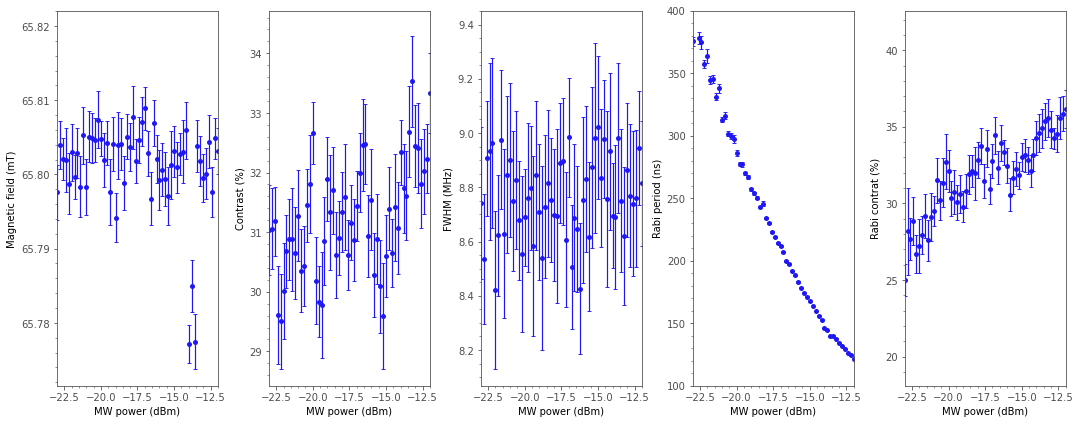

In [18]:
fig = plt.figure(figsize = (15, 6))
# plt.rcParams['figure.figsize'] = (9, 6)
fontsize = 12
ax_field = fig.add_subplot(1,5,1)
ax_contrast = fig.add_subplot(1,5,2)
ax_fwhm = fig.add_subplot(1,5,3)
ax_fit_arg_0 = fig.add_subplot(1,5,4)
ax_fit_arg_1 = fig.add_subplot(1,5,5)

ax_field.errorbar(x=power_arr, y=b_field*1e3,
                         yerr=b_field_err*1e3, fmt='o',
                         capsize=2, capthick=0.9,
                        elinewidth=1.2)
ax_contrast.errorbar(x=power_arr, y=contrast,
                         yerr=contrast_err, fmt='o',
                         capsize=2, capthick=0.9,
                        elinewidth=1.2)
ax_fwhm.errorbar(x=power_arr, y=fwhm,
                         yerr=fwhm_err, fmt='o',
                         capsize=2, capthick=0.9,
                        elinewidth=1.2)

ax_fit_arg_0.errorbar(x=power_arr, y=fit_arg_0*1e9,
                         yerr=fit_arg_0_err*1e9, fmt='o',
                         capsize=2, capthick=0.9,
                        elinewidth=1.2)

ax_fit_arg_1.errorbar(x=power_arr, y=fit_arg_1,
                         yerr=fit_arg_1_err, fmt='o',
                         capsize=2, capthick=0.9,
                        elinewidth=1.2)

ax_field.set_xlabel('MW power (dBm)')
ax_field.set_ylabel('Magnetic field (mT)')

ax_contrast.set_xlabel('MW power (dBm)')
ax_contrast.set_ylabel('Contrast (%)')

ax_fwhm.set_xlabel('MW power (dBm)')
ax_fwhm.set_ylabel('FWHM (MHz)')

ax_fit_arg_0.set_xlabel('MW power (dBm)')
ax_fit_arg_0.set_ylabel(f'Rabi period (ns)')

ax_fit_arg_1.set_xlabel('MW power (dBm)')
ax_fit_arg_1.set_ylabel(f'Rabi contrat (%)')

x_min = -23
x_max = -12
ax_field.set_xlim([x_min, x_max])
ax_contrast.set_xlim([x_min, x_max])
ax_fwhm.set_xlim([x_min, x_max])
ax_fit_arg_0.set_xlim([x_min, x_max])
ax_field.set_xlim([x_min, x_max])
ax_fit_arg_1.set_xlim([x_min, x_max])
ax_fit_arg_0.set_ylim([100, 400])

plt.tight_layout()

plt.show()

In [21]:
fit_data = {}
fit_data["Raw"] = data_array.copy()
fit_data["Fit"] = {}
fit_data["Fit"]["Rabi_period"] = fit_arg_0
fit_data["Fit"]["Rabi_period_err"] = fit_arg_0_err
fit_data["Fit"]["Rabi_contrast"] = fit_arg_1
fit_data["Fit"]["Rabi_contrast_err"] = fit_arg_1_err
fit_data["Fit"]["PODMR_field"] = b_field
fit_data["Fit"]["PODMR_field"] = b_field_err
fit_data["Fit"]["PODMR_contrast"] = contrast
fit_data["Fit"]["PODMR_contrast"] = contrast_err
fit_data["Fit"]["PODMR_FWHM"] = fwhm
fit_data["Fit"]["PODMR_FWHM_err"] = fwhm_err
fit_data["Fit"]["Power_sweep"] = power_arr


string = filebeginning+'_analysed'
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module('AttoDRY2200_Pi3_SPM\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(fit_data, f)

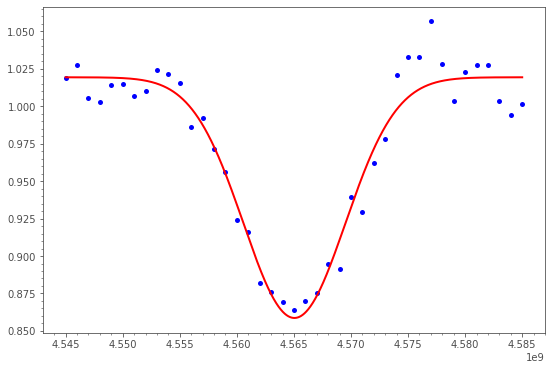

Bias field:  0.0601800990150795 T
FWHM:  10.520185209835184 MHz
Contrast:  15.762207348830518 %


In [6]:
#Analyse bias field
#Gathering data from dictonary
var_list= data_array['PODMR_sig']['coord2_arr']
data = data_array['PODMR_sig']['data'][1]

gyro_nv = 28e9 #in Hz/T
e_field = 0 #in Hz
zero_field = 2.88e9 #in Hz, watch the Temperature

mode = 'gaussian_dip'
gslac = False
left = False

fwhm_bias = 0
contrast_bias = 0

#Determine fit

if mode == 'double':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_dip)
    lm,_ = fitlogic.make_lorentziandouble_model()
    
elif mode == 'N15':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N15)
    lm,_ = fitlogic.make_lorentziandouble_model()
    
elif mode == 'N14':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N14)
    lm,_ = fitlogic.make_lorentziandouble_model()

elif mode == 'gaussian_dip':
    fit = afm_scanner_logic._fitlogic.make_gaussian_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_gaussian_dip)
    lm,_ = fitlogic.make_gaussian_model()
    fwhm_bias = fit.params['fwhm'].value*1e-6 #FWHM in MHz
    contrast_bias = fit.params['contrast'].value*-1
    
else:    
    fit = afm_scanner_logic._fitlogic.make_lorentzian_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentzian_dip)
    lm,_ = fitlogic.make_lorentzian_model()

# print(fit.fit_report())
bias_res_freq = fit.params['center'].value

if gslac == True and left == True:
    b_field_bias = np.sqrt(abs(bias_res_freq + zero_field)**2 - e_field**2) / gyro_nv
else:
    b_field_bias = np.sqrt(abs(bias_res_freq - zero_field)**2 - e_field**2) / gyro_nv

#Plot Data an
plt.plot(var_list,data,'bo')

x = np.linspace(var_list[0],var_list[-1],10000, endpoint=True)
plt.plot(x, lm.eval(fit.params, x=x),'r-')

plt.show()

print('Bias field: ',b_field_bias,'T')
print("FWHM: ",fwhm_bias,'MHz')
print("Contrast: ",contrast_bias,'%')

In [9]:
res_freq = data_array['res_freq']['data']

gyro_nv = 28e9 #in Hz/T
e_field = 0 #in Hz
zero_field = 2.88e9 #in Hz, watch the Temperature

gslac = False
left = False

if gslac == True and left == True:
    b_field = np.sqrt(abs(res_freq + zero_field)**2 - e_field**2) / gyro_nv
else:
    b_field = np.sqrt(abs(res_freq - zero_field)**2 - e_field**2) / gyro_nv
    
stray_field = b_field-b_field_bias

scan_array_x = data_array['res_freq']['coord0_arr']
scan_array_y = data_array['res_freq']['coord1_arr']
scan_start_x = scan_array_x[0]
scan_stop_x = scan_array_x[-1]
scan_start_y = scan_array_y[0]
scan_stop_y = scan_array_y[-1]

# data_array.update({'b_field': {'data': b_field}})
# data_array['b_field']['coord0_arr'] = scan_array_x
# data_array['b_field']['coord1_arr'] = scan_array_y
# data_array['b_field']['params'] = {'coord0_start': scan_start_x,'coord0_stop': scan_stop_x,'coord1_start': scan_start_y,'coord1_stop': scan_stop_y}
# data_array['b_field']['xy_units'] = 'm'
# data_array['b_field']['si_units'] = 'T'
# data_array['b_field']['nice_name'] = 'Sensed Field: B_NV'

data_array.update({'stray_field': {'data': stray_field}})
data_array['stray_field']['coord0_arr'] = scan_array_x
data_array['stray_field']['coord1_arr'] = scan_array_y
data_array['stray_field']['params'] = {'coord0_start': scan_start_x,'coord0_stop': scan_stop_x,'coord1_start': scan_start_y,'coord1_stop': scan_stop_y}
data_array['stray_field']['xy_units'] = 'm'
data_array['stray_field']['si_units'] = 'T'
data_array['stray_field']['nice_name'] = 'Stray Field: B_NV - B_bias'

with open(filepath+'_jupyter_corrected.pickle', 'wb') as f:
    pickle.dump(data_array, f)
    
save_obj_to_gwyddion(dataobj=data_array,filename=filepath+'_jupyter_corrected.gwy')